**DAY 3**

Question 1

In [1]:
#Diabetes single feature model
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
diabetes = load_diabetes(as_frame=True)
X = diabetes.data[['bmi']]
y = diabetes.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Results
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R²:", model.score(X_test, y_test))

Slope: 998.5776891375598
Intercept: 152.00335421448167
R²: 0.23335039815872138


In [2]:
#using BP
X = diabetes.data[['bp']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_bp = LinearRegression()
model_bp.fit(X_train, y_train)

print("Slope:", model_bp.coef_[0])
print("R²:", model_bp.score(X_test, y_test))

Slope: 716.3305434219111
R²: 0.1734118396354255


Question 2


In [3]:
#All feature model
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R²:", model.score(X_test, y_test))

R²: 0.4526027629719195


In [6]:
#Print Coefficient
coef_df = X.columns.to_frame(index=False)
coef_df.columns = ['Feature']
coef_df['Coefficient'] = model.coef_

print(coef_df.sort_values('Coefficient', ascending=False))

  Feature  Coefficient
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
6      s3   163.419983
9      s6    48.670657
0     age    37.904021
1     sex  -241.964362
4      s1  -931.488846


In [7]:
#Largest Positive Weight
largest_feature = X.columns[model.coef_.argmax()]
largest_coef = model.coef_.max()

print("Largest Positive Weight:")
print(largest_feature, largest_coef)

Largest Positive Weight:
s5 736.1988589046838


Question 3

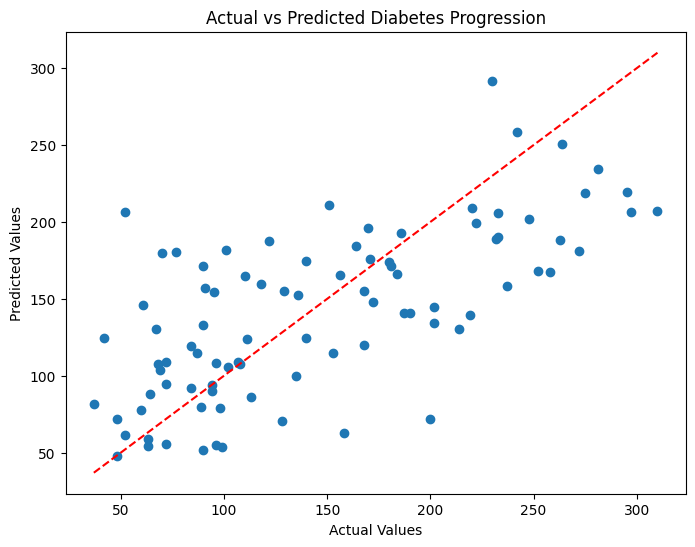

In [8]:
#Predicted vs actual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted Diabetes Progression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

Task Question 1

In [10]:
import pandas as pd

# Create DataFrame
salary_data = {
    "YearsExperience": [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.7, 3.9,
                        4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8, 7.1,
                        7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],

    "Salary": [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445,
               57189, 63218, 55794, 56957, 61111, 67938, 66029, 83088,
               81363, 93940, 91738, 98273, 101302, 113812, 109431, 105582,
               116969, 112635, 122391, 121872]
}

df = pd.DataFrame(salary_data)

# Save as CSV
df.to_csv("Salary_Data.csv", index=False)

print("CSV file created successfully!")
print(df.head())

CSV file created successfully!
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [11]:
#Build salary model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Salary_Data.csv")

# Features and target
X = df[['YearsExperience']]
y = df['Salary']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Metrics
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R²:", r2_score(y_test, pred))

Slope: 9439.88795647837
Intercept: 25779.16271249189
MAE: 4810.2474333000855
MSE: 33510305.13795559
R²: 0.9584748577664133


Question 2

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


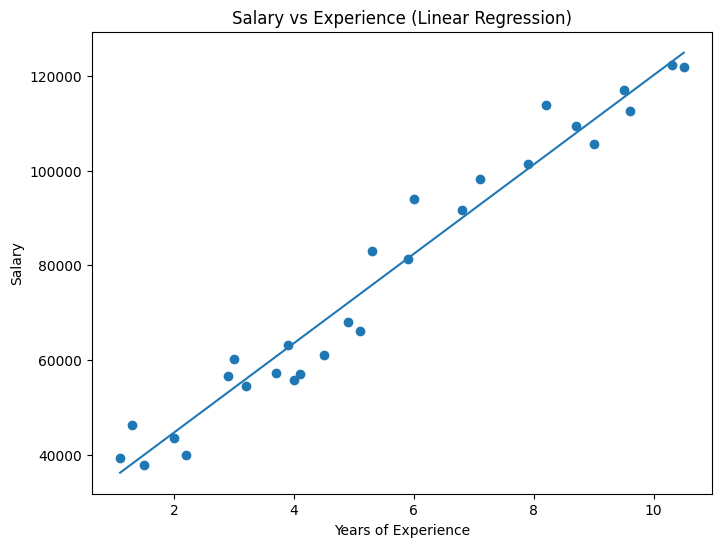

In [12]:
#plot data and best fit line
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Actual data points
plt.scatter(X, y)

# Best-fit line
x_range = np.linspace(
    X.min().values[0],
    X.max().values[0],
    100
).reshape(-1,1)

y_line = model.predict(x_range)

plt.plot(x_range, y_line)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience (Linear Regression)")

plt.show()

Question 3

The slope represents the average increase in salary for each additional year of experience. In this model, the salary increases by approximately ₹9,400 for every extra year of experience.

The intercept represents the predicted salary when years of experience is 0. It is approximately ₹25,000, which can be interpreted as the model's starting salary estimate.

The positive slope indicates a strong positive relationship between experience and salary. Employees with more experience generally earn higher salaries.

Question 4

In [13]:
#predict salary for new experience
new_exp = [[3], [7], [12]]

predictions = model.predict(new_exp)

for exp, salary in zip([3,7,12], predictions):
    print(f"{exp} years experience -> ₹{salary:,.2f}")

3 years experience -> ₹54,098.83
7 years experience -> ₹91,858.38
12 years experience -> ₹139,057.82


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
